In [1]:
import math as m
from matplotlib import pyplot as plt
import numpy as np

In [2]:
T = 300
k = 1.380649*pow(10,-23)
k_ev = 8.617333262*pow(10,-5)
h = 6.62607015*pow(10,-34)
me = 9.1093837*pow(10,-31)

In [3]:
# half ionization tempreture for Arsenic
def Nc(T): #function to calculate Nc at any temp T
    x = 2.8*pow(10,19)/pow(300,1.5)
    nc = x*pow(T,1.5)
    return nc
    
def temp1(nc,n): #function to calculate temp from nc and n value
    num = 0.054
    den = k_ev*m.log(nc/n)
    T = num/den
    return T

#half ionization tempreture for boron
def Nv(T): #funtion to calculate Nv at any T
    x = 1.04*pow(10,19)/pow(300,1.5)
    nc = x*pow(T,1.5)
    return nc
def temp2(Nv,p): #function to calcuate temp from Nv and p
    num = -0.045
    den = k_ev*m.log(p/Nv)
    T = num/den
    return T

In [4]:
t1 = 300
t2 = 0
n = 2.5*pow(10,16) #half ionization of arsenic
while(abs(t2-t1) >= 0.01):
    nc1 = Nc(t1)
    t3 = temp1(nc1,n)
    t2 = t1
    t1 = t3
    print(t1,t2,t3)

89.25174257443979 300 89.25174257443979
120.44819463901058 89.25174257443979 120.44819463901058
110.86648722632987 120.44819463901058 110.86648722632987
113.3602183795643 110.86648722632987 113.3602183795643
112.6800938183738 113.3602183795643 112.6800938183738
112.86328482142284 112.6800938183738 112.86328482142284
112.81377522834184 112.86328482142284 112.81377522834184
112.82714358606589 112.81377522834184 112.82714358606589
112.82353303184006 112.82714358606589 112.82353303184006


In [5]:
t1 = 300
t2 = 0
p = 2*pow(10,15) #half ionization of boron
while(abs(t2-t1) >= 0.01):
    nv1 = Nv(t1)
    t3 = temp2(nv1,p)
    t2 = t1
    t1 = t3
    print(t1,t2,t3)

61.03062817001766 300 61.03062817001766
84.66600423433242 61.03062817001766 84.66600423433242
78.42290195991626 84.66600423433242 78.42290195991626
79.79984149037358 78.42290195991626 79.79984149037358
79.48272899856553 79.79984149037358 79.48272899856553
79.55505056503894 79.48272899856553 79.55505056503894
79.53851974336757 79.55505056503894 79.53851974336757
79.54229632670784 79.53851974336757 79.54229632670784


In [6]:
# 10 times intrinsic carrier conc
def temp3(ni,Nc,Nv,eg): #function to calculte temp using ni,nc,eg value.
    no = pow(Nc*Nv,0.5)
    T = eg/(2*k_ev*m.log(no/ni))
    return T
def E_g(T):
    Eg = 1.17 - 4.73*pow(10,-4)*pow(T,2)/(T+636) 
    return Eg

In [7]:
#calcukation for arsenic
ni = 5*pow(10,17) #ten times dopant concentration value
t1 = 300
t2 = 0
while(abs(t2-t1) >= 0.001):
    nv = Nv(t1)
    nc = Nc(t1)
    eg = E_g(t1)
    t3 = temp3(ni,nc,nv,eg)
    t2 = t1
    t1 = t3
print(t1,t2)

975.383092592695 975.3839391920252


In [8]:
#verification
pow(Nv(t1)*Nc(t1),0.5)*m.exp(-E_g(t1)/(2*k_ev*t1))

4.999983435200939e+17

In [14]:
e_fermi = 0.56 + 0.026*m.log(5*pow(10,15)/1.5*pow(10,10))
e_fermi

2.0879836033586043

In [9]:
#calcukation for boron
ni = 4*pow(10,16) #ten times dopant concentration value
t1 = 300 
t2 = 0
while(abs(t2-t1) >= 0.001):
    nv = Nv(t1)
    nc = Nc(t1)
    eg = E_g(t1)
    t3 = temp3(ni,nc,nv,eg)
    t2 = t1
    t1 = t3
print(t1,t2)

759.1883499415534 759.1876891402032


In [10]:
#verification
pow(Nv(t1)*Nc(t1),0.5)*m.exp(-E_g(t1)/(2*k_ev*t1))

4.000012792065023e+16

In [22]:
0.026*m.log(4.23*pow(10,6)) + 0.56

0.956700526326584

In [11]:
summ = 0
step = 0.001
e_c = 1.1
e_vac = 8.152
bands = np.arange(e_c,e_vac,step)
for i in bands :
    summ = summ + (step*carrier_conc(i,0.56,300))
print(summ)

NameError: name 'carrier_conc' is not defined

# Donor Ionization Energy

In [61]:
m_e = 9.1093837*pow(10,-31)
def h_ion(m,e_r):
    return ((1/pow(e_r,2))*13.6*m)

In [97]:
# N doped
si_li = (0.033,h_ion(0.26,11.7))
si_sb = (0.039,h_ion(0.26,11.7))
d_p = (0.52,h_ion(0.48,5.7))
ge_li = (0.0039,h_ion(0.22,16.2))
ge_sb = (0.0096,h_ion(0.22,16.2))
gan_si = (0.015,h_ion(0.2,8.9))

In [98]:
# P doped
si_b = (0.37,h_ion(0.36,11.7))
ge_b = (0.01,h_ion(0.21,16.2))
ge_al = (0.01,h_ion(0.21,16.2))
gan_mg = (0.224,h_ion(1.5,8.9))
d_b = (0.37,h_ion(0.57,5.7))

In [99]:
p = [si_b,ge_b,ge_al,gan_mg,d_b,ge_b]
n = [si_li,si_sb,ge_li,ge_sb,gan_si]
print(p)
print(n)

[(0.37, 0.03576594345825115), (0.01, 0.010882487425697302), (0.01, 0.010882487425697302), (0.224, 0.2575432394899634), (0.37, 0.2385964912280701), (0.01, 0.010882487425697302)]
[(0.033, 0.025830959164292497), (0.039, 0.025830959164292497), (0.0039, 0.01140070111263527), (0.0096, 0.01140070111263527), (0.015, 0.034339098598661785)]


<Figure size 1440x1440 with 0 Axes>

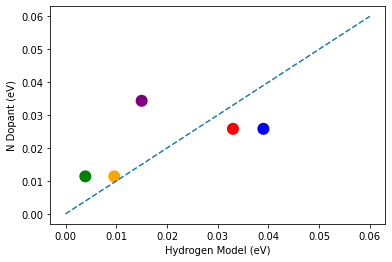

<Figure size 1440x1440 with 0 Axes>

In [109]:
colors = ['red', 'blue', 'green', 'orange', 'purple']
plt.scatter(*zip(*n),c = colors, linewidth = 6)
plt.plot((0,0.06),(0,0.06), linestyle = '--')
# plt.legend()
plt.xlabel('Hydrogen Model (eV)')
plt.ylabel('N Dopant (eV)')
plt.figure(figsize=(20,20))
# plt.scatter(*zip(*n))

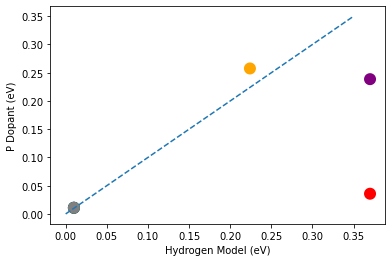

In [108]:
colors = ['red', 'blue', 'green', 'orange', 'purple','grey']
plt.scatter(*zip(*p),c = colors , linewidth = 6)
plt.xlabel('Hydrogen Model (eV)')
plt.ylabel('P Dopant (eV)')
plt.plot((0,0.35),(0,0.35), linestyle = '--')

In [74]:
p

[(0.37, 0.03576594345825115),
 (0.01, 0.01761926535589087),
 (0.01, 0.01761926535589087),
 (0.224, 0.2575432394899634),
 (0.37, 0.3348722683902739),
 (0.01, 0.01761926535589087)]

In [18]:
#fermi level when Arsenic is fully ionzed
ar = 5*pow(10,16)
ni = 1.5*pow(10,10)
e_f_ar = E_g(300)/2 + k_ev*300*m.log(ar/ni)
e_f_ar

0.9505432960523725

In [20]:
#fermi level when Boron is fully ionzed
b = 4*pow(10,15)
ni = 1.5*pow(10,10)
e_f_b = E_g(300)/2 - k_ev*300*m.log(b/ni)
e_f_b

0.2392710710890093

In [21]:
dopants = ar-b
e_f_b_ar = E_g(300)/2 + k_ev*300*m.log(dopants/ni)
e_f_b_ar

0.9483877147159238